In [33]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
%matplotlib inline 
sns.set(style="ticks")

## Загрузка и первичный анализ данных

In [34]:
data = pd.read_csv('avocado.csv', sep=",")

In [35]:
data.shape

(18249, 14)

In [36]:
data.dtypes

Unnamed: 0        int64
Date             object
AveragePrice    float64
Total Volume    float64
4046            float64
4225            float64
4770            float64
Total Bags      float64
Small Bags      float64
Large Bags      float64
XLarge Bags     float64
type             object
year              int64
region           object
dtype: object

In [37]:
data.isnull().sum()

Unnamed: 0      0
Date            0
AveragePrice    0
Total Volume    0
4046            0
4225            0
4770            0
Total Bags      0
Small Bags      0
Large Bags      0
XLarge Bags     0
type            0
year            0
region          0
dtype: int64

In [38]:
data.head()

,Unnamed: 0,Date,AveragePrice,Total Volume,4046,4225,4770,Total Bags,Small Bags,Large Bags,XLarge Bags,type,year,region
0,0,2015-12-27,1.33,64236.62,1036.74,54454.85,48.16,8696.87,8603.62,93.25,0.0,conventional,2015,Albany
1,1,2015-12-20,1.35,54876.98,674.28,44638.81,58.33,9505.56,9408.07,97.49,0.0,conventional,2015,Albany
2,2,2015-12-13,0.93,118220.22,794.70,109149.67,130.50,8145.35,8042.21,103.14,0.0,conventional,2015,Albany
3,3,2015-12-06,1.08,78992.15,1132.00,71976.41,72.58,5811.16,5677.40,133.76,0.0,conventional,2015,Albany
4,4,2015-11-29,1.28,51039.60,941.48,43838.39,75.78,6183.95,5986.26,197.69,0.0,conventional,2015,Albany


In [39]:
total_count = data.shape[0]
print('Всего строк: {}'.format(total_count))

Всего строк: 18249


## Кодирование категориальных признаков

In [40]:
data_new = data.drop(['Date'], axis=1)

In [41]:
data_new = pd.get_dummies(data, columns=['region'], drop_first=True)

In [42]:
data_new['type'] = data['type'].map({'conventional': 0, 'organic': 1})

In [43]:
data_new.head()

,Unnamed: 0,Date,AveragePrice,Total Volume,4046,4225,4770,Total Bags,Small Bags,Large Bags,...,region_SouthCarolina,region_SouthCentral,region_Southeast,region_Spokane,region_StLouis,region_Syracuse,region_Tampa,region_TotalUS,region_West,region_WestTexNewMexico
0,0,2015-12-27,1.33,64236.62,1036.74,54454.85,48.16,8696.87,8603.62,93.25,...,False,False,False,False,False,False,False,False,False,False
1,1,2015-12-20,1.35,54876.98,674.28,44638.81,58.33,9505.56,9408.07,97.49,...,False,False,False,False,False,False,False,False,False,False
2,2,2015-12-13,0.93,118220.22,794.70,109149.67,130.50,8145.35,8042.21,103.14,...,False,False,False,False,False,False,False,False,False,False
3,3,2015-12-06,1.08,78992.15,1132.00,71976.41,72.58,5811.16,5677.40,133.76,...,False,False,False,False,False,False,False,False,False,False
4,4,2015-11-29,1.28,51039.60,941.48,43838.39,75.78,6183.95,5986.26,197.69,...,False,False,False,False,False,False,False,False,False,False


## Обучающая и тестовая выборки

In [44]:
split_idx = int(0.8 * len(data_new))
data_train = data_new.iloc[:split_idx].copy()   # обучающая таблица
data_test  = data_new.iloc[split_idx:].copy()   # тестовая таблица

In [45]:
X_train = data_train[['Total Volume', 'Total Bags']]
Y_train = data_train['AveragePrice']

In [46]:
def price_to_class(AveragePrice: float) -> str:
    if AveragePrice < 1:
        result = 'Очень дешевые'
    elif AveragePrice < 1.5:
        result = 'Дешевые'
    elif AveragePrice < 2:
        result = 'Средние'
    else:
        result = 'Дорогие'        
    return result 

In [47]:
data_train['type'] = \
data_train.apply(lambda row: price_to_class(row['AveragePrice']),axis=1)

In [48]:
data_train

,Unnamed: 0,Date,AveragePrice,Total Volume,4046,4225,4770,Total Bags,Small Bags,Large Bags,...,region_SouthCarolina,region_SouthCentral,region_Southeast,region_Spokane,region_StLouis,region_Syracuse,region_Tampa,region_TotalUS,region_West,region_WestTexNewMexico
0,0,2015-12-27,1.33,64236.62,1036.74,54454.85,48.16,8696.87,8603.62,93.25,...,False,False,False,False,False,False,False,False,False,False
1,1,2015-12-20,1.35,54876.98,674.28,44638.81,58.33,9505.56,9408.07,97.49,...,False,False,False,False,False,False,False,False,False,False
2,2,2015-12-13,0.93,118220.22,794.70,109149.67,130.50,8145.35,8042.21,103.14,...,False,False,False,False,False,False,False,False,False,False
3,3,2015-12-06,1.08,78992.15,1132.00,71976.41,72.58,5811.16,5677.40,133.76,...,False,False,False,False,False,False,False,False,False,False
4,4,2015-11-29,1.28,51039.60,941.48,43838.39,75.78,6183.95,5986.26,197.69,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14594,9,2016-10-23,1.63,699763.35,131203.12,241758.21,4363.02,322439.00,168962.60,153476.40,...,False,False,False,False,False,False,False,True,False,False
14595,10,2016-10-16,1.50,815859.49,114303.56,243788.95,4732.27,453034.71,250864.40,202170.31,...,False,False,False,False,False,False,False,True,False,False
14596,11,2016-10-09,1.52,878367.41,127092.78,266687.47,5103.42,479483.74,289726.54,189757.20,...,False,False,False,False,False,False,False,True,False,False
14597,12,2016-10-02,1.71,790926.03,131467.24,272293.48,4904.25,382261.06,282727.98,99533.08,...,False,False,False,False,False,False,False,True,False,False


In [49]:
X_test = data_test[['Total Volume', 'Total Bags']]
Y_test = data_test['AveragePrice'].apply(price_to_class) 

In [50]:
data_train['price_class'] = data_train['AveragePrice'].apply(price_to_class)
data_test['price_class']  = data_test['AveragePrice'].apply(price_to_class)

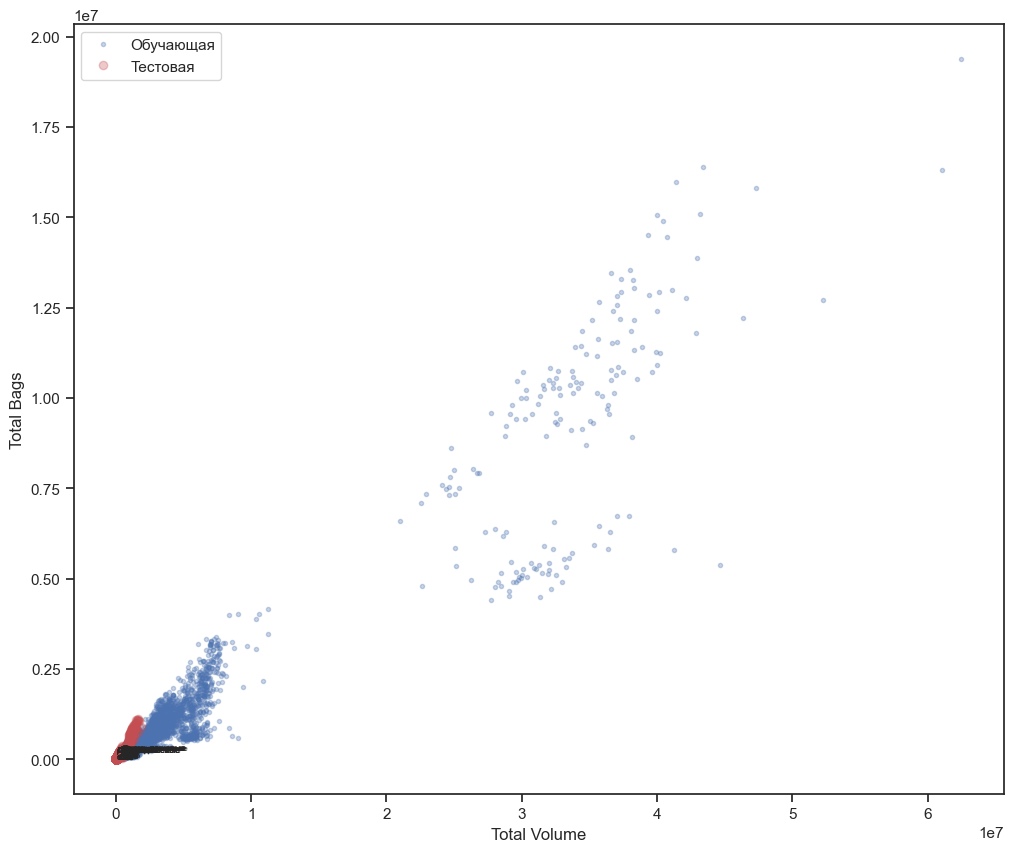

In [51]:
fig, ax = plt.subplots(figsize=(12, 10))

ax.plot(data_train['Total Volume'], data_train['Total Bags'], 'b.', label='Обучающая', alpha=0.3)
ax.plot(data_test['Total Volume'], data_test['Total Bags'], 'ro', label='Тестовая', alpha=0.3)

# Подписи только для первых 100 строк обучающей выборки
for _, row in data_train.head(100).iterrows():
    x1 = row['Total Volume']
    x2 = row['Total Bags']
    y_val = round(row['AveragePrice'], 2)
    cat = row['price_class']
    ax.text(x1, x2, f'{cat}\n{y_val}', fontsize=6, alpha=0.7)

plt.xlabel('Total Volume')
plt.ylabel('Total Bags')
plt.legend()
plt.show()

## Метод (алгоритм) k-ближайших соседей

In [52]:
from operator import itemgetter
import math
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix,
                             precision_score, recall_score, f1_score)
from sklearn.model_selection import (GridSearchCV, RandomizedSearchCV,
                                     KFold, StratifiedKFold, cross_val_score)

In [53]:
from enum import Enum
class PredictionType(Enum):
    CLASSIFICATION = 1
    REGRESSION = 2


Признаки масштабированы (среднее=0, дисперсия=1).

=== Исходная модель (K=5) ===
Accuracy : 0.3208
               precision    recall  f1-score   support

      Дешевые       0.28      0.51      0.36      1032
      Дорогие       0.51      0.06      0.11       763
Очень дешевые       0.06      0.23      0.10       120
      Средние       0.46      0.33      0.39      1735

     accuracy                           0.32      3650
    macro avg       0.33      0.28      0.24      3650
 weighted avg       0.41      0.32      0.31      3650


GridSearchCV (KFold): лучший K = 45, CV accuracy = 0.6399
RandomizedSearchCV (StratifiedKFold): лучший K = 33, CV accuracy = 0.6371

=== Сравнение на тестовой выборке ===
Модель с произвольным K=5:       Accuracy = 0.3208
Модель с K=45 (GridSearchCV):   Accuracy = 0.3279
Модель с K=33 (RandomizedSearchCV): Accuracy = 0.3244


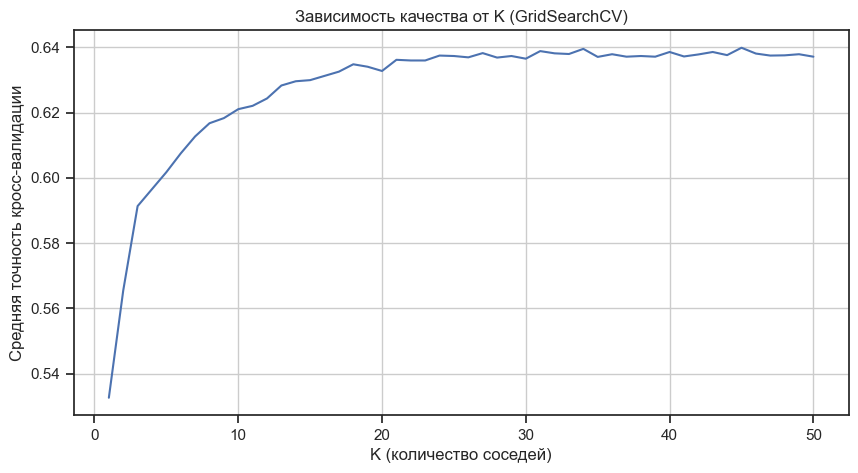

In [57]:
import warnings
warnings.filterwarnings('ignore')

assert 'price_class' in data_train.columns
assert 'price_class' in data_test.columns

X_train = data_train[['Total Volume', 'Total Bags']].copy()
y_train = data_train['price_class'].copy()

X_test  = data_test[['Total Volume', 'Total Bags']].copy()
y_test  = data_test['price_class'].copy()  

# =============================================================================
# 2. Масштабирование признаков (необходимо для KNN)
# =============================================================================

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nПризнаки масштабированы (среднее=0, дисперсия=1).")

# =============================================================================
# 3. Обучение модели KNN с произвольным гиперпараметром K (например K=5)
# =============================================================================

k_initial = 5
knn_init = KNeighborsClassifier(n_neighbors=k_initial)
knn_init.fit(X_train_scaled, y_train)
y_pred_init = knn_init.predict(X_test_scaled)

print("\n=== Исходная модель (K=5) ===")
print(f"Accuracy : {accuracy_score(y_test, y_pred_init):.4f}")
print(classification_report(y_test, y_pred_init))

# ==============================
# 4. ПОДБОР ГИПЕРПАРАМЕТРА K с GridSearchCV (KFold)
# ==============================
param_grid = {'n_neighbors': list(range(1, 51))}

grid = GridSearchCV(KNeighborsClassifier(), param_grid,
                    cv=KFold(n_splits=5, shuffle=True, random_state=42),
                    scoring='accuracy', n_jobs=-1)
grid.fit(X_train_scaled, y_train)
best_k_grid = grid.best_params_['n_neighbors']
print(f"\nGridSearchCV (KFold): лучший K = {best_k_grid}, CV accuracy = {grid.best_score_:.4f}")

# ==============================
# 5. ПОДБОР ГИПЕРПАРАМЕТРА K с RandomizedSearchCV (StratifiedKFold)
# ==============================
random_search = RandomizedSearchCV(KNeighborsClassifier(), param_grid,
                                   n_iter=30, random_state=42,
                                   cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
                                   scoring='accuracy', n_jobs=-1)
random_search.fit(X_train_scaled, y_train)
best_k_rand = random_search.best_params_['n_neighbors']
print(f"RandomizedSearchCV (StratifiedKFold): лучший K = {best_k_rand}, CV accuracy = {random_search.best_score_:.4f}")

# ==============================
# 6. ОЦЕНКА ОПТИМАЛЬНЫХ МОДЕЛЕЙ НА ТЕСТЕ
# ==============================
knn_grid = KNeighborsClassifier(n_neighbors=best_k_grid).fit(X_train_scaled, y_train)
knn_rand = KNeighborsClassifier(n_neighbors=best_k_rand).fit(X_train_scaled, y_train)

acc_grid = accuracy_score(y_test, knn_grid.predict(X_test_scaled))
acc_rand = accuracy_score(y_test, knn_rand.predict(X_test_scaled))

print("\n=== Сравнение на тестовой выборке ===")
print(f"Модель с произвольным K={k_initial}:       Accuracy = {accuracy_score(y_test, y_pred_init):.4f}")
print(f"Модель с K={best_k_grid} (GridSearchCV):   Accuracy = {acc_grid:.4f}")
print(f"Модель с K={best_k_rand} (RandomizedSearchCV): Accuracy = {acc_rand:.4f}")

# ==============================
# 7. ВИЗУАЛИЗАЦИЯ
# ==============================
# График точности от K по результатам GridSearchCV
results = pd.DataFrame(grid.cv_results_)
plt.figure(figsize=(10,5))
plt.plot(results['param_n_neighbors'], results['mean_test_score'])
plt.xlabel('K (количество соседей)')
plt.ylabel('Средняя точность кросс-валидации')
plt.title('Зависимость качества от K (GridSearchCV)')
plt.grid(True)
plt.show()